# Phase 2 - Kham pha du lieu va huan luyen LOF bang scikit-learn

Notebook nay tach rieng phase 2 de trinh bay day du quy trinh: kham pha du lieu, cài dat LOF bang scikit-learn, thu nghiem hyperparameters va truc quan hoa cac diem outlier tren tap du lieu da lam sach.

Du lieu dau vao duoc lay tu file `creditcard_preprocessed_for_lof.csv` da tao o phase 1.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

DATA_PATH = Path('../data/processed/creditcard_preprocessed_for_lof.csv')
FIG_DIR = Path('../data/figures/phase2')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'Class'
RANDOM_STATE = 42
N_NEIGHBORS_GRID = [10, 15, 20, 25, 30, 40, 50, 75]

## 3.1. Mo ta du lieu va kham pha so bo

Phan nay kiem tra kich thuoc tap du lieu, do mat can bang giua hai lop `Class`, va so luong missing/duplicate con lai sau tien xu ly.

Vi LOF la thuat toan dua tren khoang cach, notebook dung lai file da lam sach va chuan hoa them toan bo dac trung bang `RobustScaler` de cac chieu du lieu co do lon tuong doi dong nhat hon.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Khong tim thay file du lieu: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
feature_cols = [col for col in df.columns if col != TARGET_COL]
X_raw = df[feature_cols].copy()
y = df[TARGET_COL].astype(int).copy()

scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=feature_cols,
    index=df.index
)

fraud_rate = float(y.mean())

print(f'Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Feature columns: {len(feature_cols)}')
print(f'Fraud rate in cleaned set: {fraud_rate:.4%}')
print(f'Missing values: {int(df.isna().sum().sum()):,}')
print(f'Duplicate rows: {int(df.duplicated().sum()):,}')
display(y.value_counts().rename('count').to_frame())
display(df.head())

Loaded cleaned dataset: 10,473 rows x 31 columns
Feature columns: 30
Fraud rate in cleaned set: 4.5164%
Missing values: 0
Duplicate rows: 0


,count
Class,
0,10000
1,473


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.373702,-1.080483,0.846986,-0.394352,-0.558698,1.590957,1.333946,0.499037,0.873895,-0.633218,-1.695323,-0.018668,0.174666,0.023227,-0.688044,0.889949,-0.912170,1.871919,-1.492511,-1.880440,-0.125842,0.330110,0.905075,-0.100022,-0.729690,-0.051358,0.554370,0.007865,0.046606,0.458907,0
1,0.434153,-0.316294,0.093598,-0.182054,-0.464817,2.900275,4.142079,-0.172407,1.195041,0.278999,-0.707168,-0.757462,0.369412,-0.531936,-0.159520,-1.198724,-0.490853,-0.224625,-0.844563,-0.072429,-0.066127,-0.431264,-1.245281,0.241595,0.608262,-0.377637,-1.130772,0.131027,0.070772,-0.041024,0
2,0.231552,-1.049225,-0.072280,1.566195,-2.871399,-0.901545,-0.831067,-0.516465,0.522248,3.203277,-2.739069,-0.617220,-2.622706,0.524453,1.454934,-0.134486,0.624582,-0.113408,1.151208,-1.072218,-0.317210,0.232372,0.733776,-0.100061,-0.174101,-0.307925,-0.432352,0.014496,0.056275,0.284800,0
3,-0.563059,-0.859577,0.913379,1.634410,-1.352680,-0.023133,-0.515547,0.595465,-0.097411,-0.016912,-0.663406,-0.176540,0.273846,0.452144,-0.187898,0.720024,0.255492,-0.440935,-0.868098,-1.008776,-0.149700,0.054760,-0.016846,-0.046817,0.134409,-0.502241,0.689326,-0.376266,0.102777,-0.207621,0
4,-0.037189,1.334298,-1.552223,0.937684,-1.419113,-1.908205,0.042943,-1.587986,0.018680,-1.263985,1.331458,-1.223005,-0.894342,1.413636,-0.917562,1.174311,0.429097,-0.126896,0.930854,-0.378808,-0.045294,0.083608,0.487591,-0.195867,-0.434731,0.298962,-0.000923,0.068064,0.047571,1.209846,0


## 3.2. Truc quan hoa phan bo va tuong quan

Truoc khi huan luyen LOF, can quan sat phan bo `Class`, xem giao dich `Amount`/`Time` va do tuong quan giua cac dac trung. Cac hinh duoc luu voi do phan giai cao trong thu muc `../data/figures/phase2`.

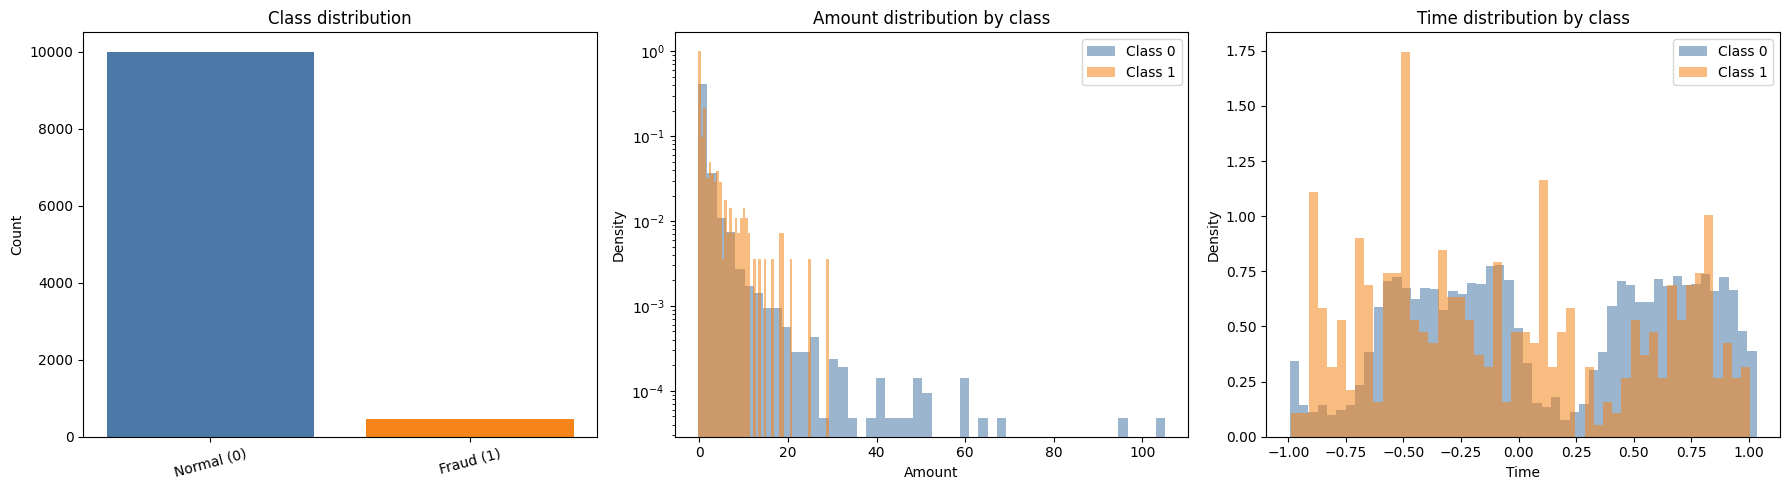

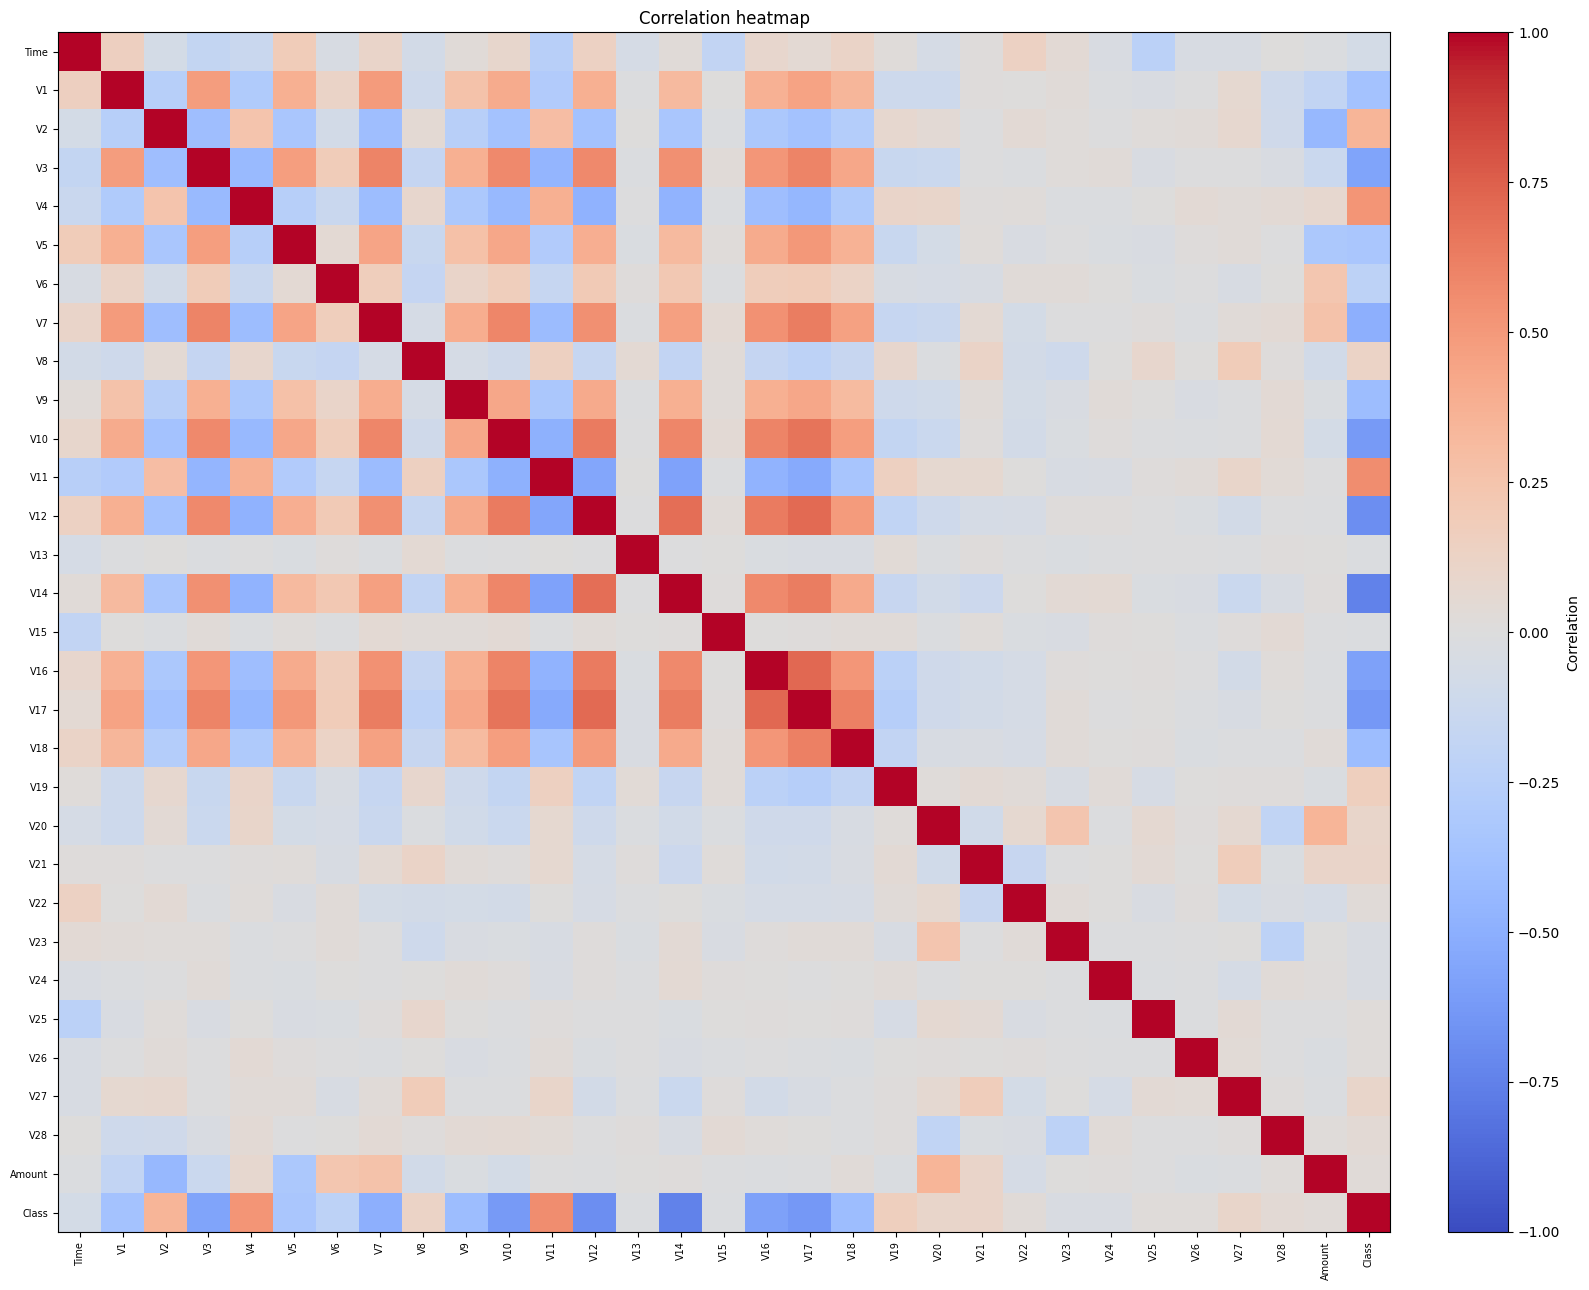

,corr_with_Class
V14,-0.746779
V12,-0.686958
V17,-0.631088
V10,-0.618573
V16,-0.581999
V3,-0.566958
V11,0.562336
V4,0.520194
V7,-0.496979
V18,-0.405584


In [3]:
# 1) Phan bo lop va phan bo Amount/Time theo Class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_counts = y.value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Fraud (1)'], class_counts.reindex([0, 1], fill_value=0).values, color=['#4C78A8', '#F58518'])
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

for label, color in [(0, '#4C78A8'), (1, '#F58518')]:
    subset = df[df[TARGET_COL] == label]
    axes[1].hist(subset['Amount'], bins=50, alpha=0.55, density=True, label=f'Class {label}', color=color)
axes[1].set_title('Amount distribution by class')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_yscale('log')

for label, color in [(0, '#4C78A8'), (1, '#F58518')]:
    subset = df[df[TARGET_COL] == label]
    axes[2].hist(subset['Time'], bins=50, alpha=0.55, density=True, label=f'Class {label}', color=color)
axes[2].set_title('Time distribution by class')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Density')
axes[2].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'phase2_eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Ma tran tuong quan
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.index, fontsize=7)
ax.set_title('Correlation heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
fig.tight_layout()
fig.savefig(FIG_DIR / 'phase2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

corr_target = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_target.head(10).rename('corr_with_Class').to_frame())

## 3.3. Cai dat thuat toan LOF va huan luyen mo hinh

`LocalOutlierFactor` duoc su dung de tinh do bat thuong cua tung giao dich. Trong bai nay, `Class = 1` duoc xem la outlier/gian lan, con `Class = 0` la giao dich binh thuong. De danh gia, ta giu `contamination` xap xi theo ty le gian lan thuc te trong tap da xu ly va thay doi `n_neighbors` de so sanh.

In [4]:
def run_lof_experiment(X_values: np.ndarray, y_true: pd.Series, n_neighbors: int, contamination: float) -> dict:
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        metric='minkowski'
    )
    raw_pred = lof.fit_predict(X_values)
    y_pred = (raw_pred == -1).astype(int)
    anomaly_score = -lof.negative_outlier_factor_

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {
        'n_neighbors': n_neighbors,
        'contamination': contamination,
        'predicted_outlier_rate': float(y_pred.mean()),
        'precision_fraud': precision_score(y_true, y_pred, zero_division=0),
        'recall_fraud': recall_score(y_true, y_pred, zero_division=0),
        'f1_fraud': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, anomaly_score),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }
    return {
        'model': lof,
        'y_pred': y_pred,
        'anomaly_score': anomaly_score,
        'metrics': metrics,
    }

X_values = X_scaled.to_numpy()
contamination = fraud_rate
experiment_rows = []
experiment_store = {}

for n_neighbors in N_NEIGHBORS_GRID:
    output = run_lof_experiment(X_values, y, n_neighbors, contamination)
    experiment_store[n_neighbors] = output
    experiment_rows.append(output['metrics'])

results_df = pd.DataFrame(experiment_rows).sort_values(['f1_fraud', 'recall_fraud', 'roc_auc'], ascending=False).reset_index(drop=True)
display(results_df)

best_n_neighbors = int(results_df.iloc[0]['n_neighbors'])
best_output = experiment_store[best_n_neighbors]
print(f'Best n_neighbors theo f1_fraud: {best_n_neighbors}')
print(f'Contamination su dung: {contamination:.4%}')

,n_neighbors,contamination,predicted_outlier_rate,precision_fraud,recall_fraud,f1_fraud,roc_auc,tn,fp,fn,tp
0,75,0.045164,0.045164,0.133192,0.133192,0.133192,0.629253,9590,410,410,63
1,40,0.045164,0.045164,0.131078,0.131078,0.131078,0.580064,9589,411,411,62
2,50,0.045164,0.045164,0.124736,0.124736,0.124736,0.599654,9586,414,414,59
3,30,0.045164,0.045164,0.116279,0.116279,0.116279,0.556715,9582,418,418,55
4,25,0.045164,0.045164,0.109937,0.109937,0.109937,0.544596,9579,421,421,52
5,20,0.045164,0.045164,0.099366,0.099366,0.099366,0.525741,9574,426,426,47
6,15,0.045164,0.045164,0.082452,0.082452,0.082452,0.517067,9566,434,434,39
7,10,0.045164,0.045164,0.069767,0.069767,0.069767,0.492593,9560,440,440,33


Best n_neighbors theo f1_fraud: 75
Contamination su dung: 4.5164%


In [ ]:
# Bao cao chi tiet va so sanh hyperparameter
best_y_pred = best_output['y_pred']
print('Classification report cho best model:')
print(classification_report(y, best_y_pred, target_names=['Normal', 'Fraud'], digits=4, zero_division=0))

metrics_plot_df = results_df.sort_values('n_neighbors')
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(metrics_plot_df['n_neighbors'], metrics_plot_df['precision_fraud'], marker='o', label='Precision')
ax.plot(metrics_plot_df['n_neighbors'], metrics_plot_df['recall_fraud'], marker='o', label='Recall')
ax.plot(metrics_plot_df['n_neighbors'], metrics_plot_df['f1_fraud'], marker='o', label='F1')
ax.plot(metrics_plot_df['n_neighbors'], metrics_plot_df['roc_auc'], marker='o', label='ROC-AUC')
ax.set_title('LOF performance by n_neighbors')
ax.set_xlabel('n_neighbors')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'phase2_hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

display(metrics_plot_df[['n_neighbors', 'precision_fraud', 'recall_fraud', 'f1_fraud', 'roc_auc', 'predicted_outlier_rate']])

## 3.4. Danh gia hieu suat va phan tich tham so

Khi thay doi `n_neighbors`, mo hinh LOF se thay doi cach uoc luong mat do cuc bo quanh moi giao dich. `n_neighbors` nho lam mo hinh nhay voi bien dong cuc bo, de tang recall nhung co the sinh them false positive. `n_neighbors` lon hon lam mo hinh on dinh hon, thuong giam false positive nhung co the bo sot mot so giao dich gian lan y nao ro.

Trong notebook nay, tham so tot nhat duoc chon theo `f1_fraud`, sau do doi chieu them voi `recall_fraud` va `roc_auc` de dam bao can bang giua phat hien gian lan va so luong canh bao sai.

## 3.5. Truc quan hoa ket qua

Hinh ben duoi dung PCA 2 chieu de chieu du lieu nhieu chieu xuong mat phang, sau do to mau cac giao dich bi LOF danh dau la outlier va khong gian lan thuc te de doi chieu.

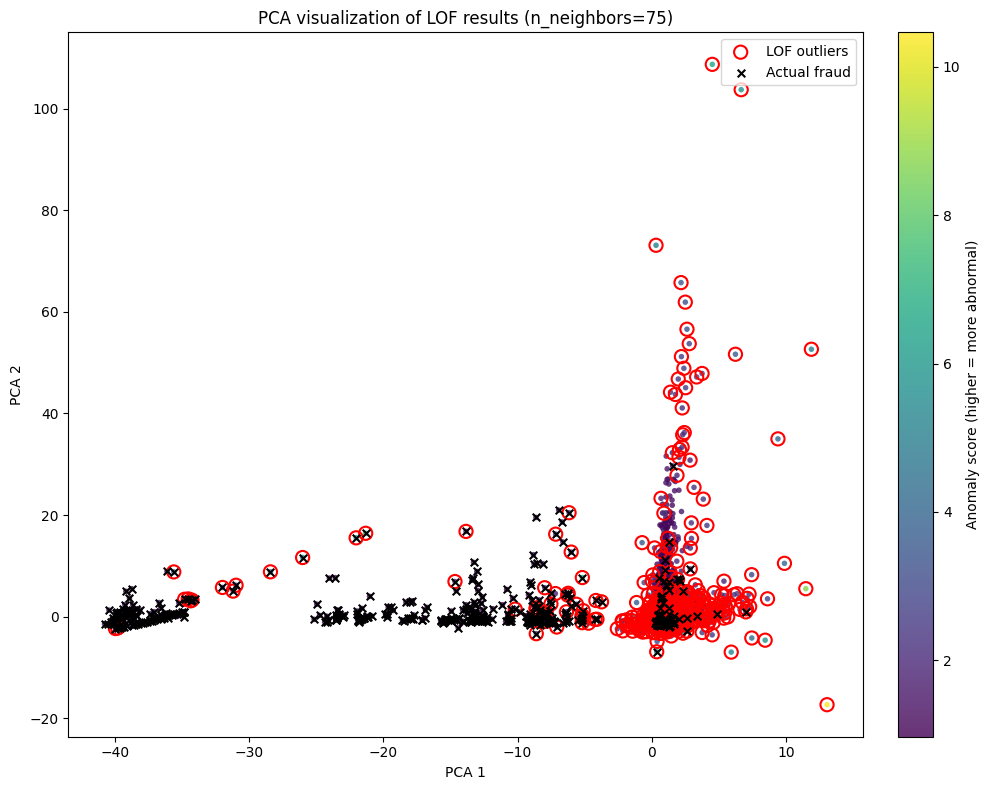

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_values)

best_y_pred = best_output['y_pred']
fraud_mask = y.to_numpy() == 1
detected_mask = best_y_pred == 1

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=best_output['anomaly_score'],
    cmap='viridis',
    s=16,
    alpha=0.8,
    linewidths=0,
)
ax.scatter(
    X_2d[detected_mask, 0],
    X_2d[detected_mask, 1],
    facecolors='none',
    edgecolors='red',
    s=90,
    linewidths=1.5,
    label='LOF outliers',
)
ax.scatter(
    X_2d[fraud_mask, 0],
    X_2d[fraud_mask, 1],
    marker='x',
    color='black',
    s=30,
    label='Actual fraud',
)
ax.set_title(f'PCA visualization of LOF results (n_neighbors={best_n_neighbors})')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(loc='best')
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Anomaly score (higher = more abnormal)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'phase2_lof_pca_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

### Ket luan rut gon

Notebook nay da cung cap: (1) EDA tren tap du lieu da lam sach, (2) cài dat LOF bang scikit-learn, (3) so sanh `n_neighbors`, va (4) truc quan hoa cac diem outlier tren khong gian PCA 2 chieu. Cac hinh da duoc luu voi do phan giai cao trong `../data/figures/phase2`.